# IMAGE PREPROCESSING
## Image Processing / Computer Vision

### Fundamentals of Image Preprocessing

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving my_image.jpg to my_image.jpg


In [3]:
# Get the uploaded filename automatically
filename = next(iter(uploaded))

# Read the image using OpenCV
image = cv2.imread(filename)

if image is None:
    print("Error: Image could not be loaded.")
else:
    print("Image uploaded successfully!")
    print("Filename:", filename)

Image uploaded successfully!
Filename: my_image.jpg


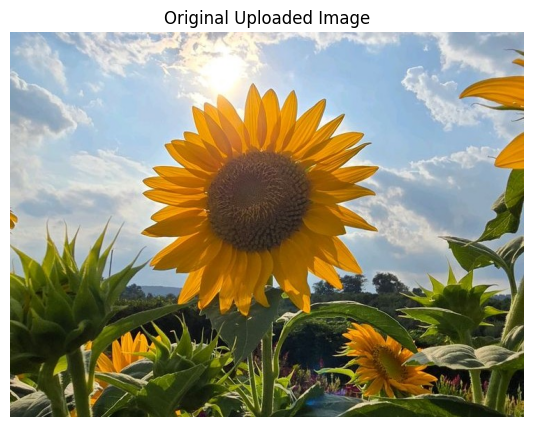

In [4]:
# Convert BGR to RGB for displaying with Matplotlib
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(rgb_image)
plt.title("Original Uploaded Image")
plt.axis("off")
plt.show()

# Task 1 – Image Loading and Inspection

In [5]:
# Get image dimensions
height, width = image.shape[:2]

# Get number of channels
if len(image.shape) == 2:
    channels = 1
else:
    channels = image.shape[2]

print("IMAGE INFORMATION")
print("------------------")
print("Filename:", filename)
print("Width:", width)
print("Height:", height)
print("Channels:", channels)
print("Data Type:", image.dtype)
print("Minimum Pixel Value:", image.min())
print("Maximum Pixel Value:", image.max())

IMAGE INFORMATION
------------------
Filename: my_image.jpg
Width: 736
Height: 552
Channels: 3
Data Type: uint8
Minimum Pixel Value: 0
Maximum Pixel Value: 255


# Task 2 – Color Space Conversion

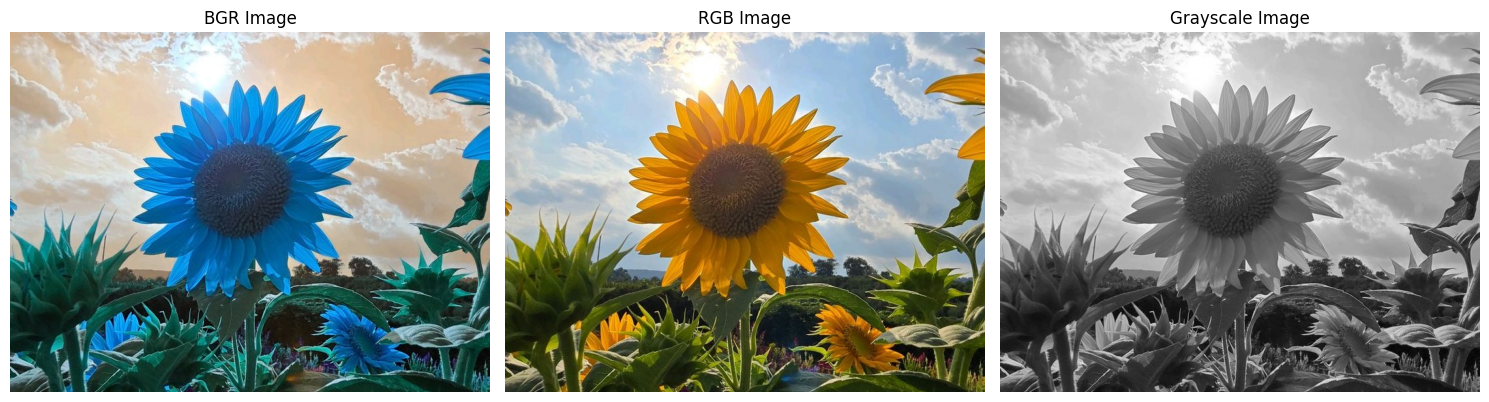

In [6]:
# Convert BGR to RGB
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert BGR to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display all versions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("BGR Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(rgb_image)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# Task 3 – Image Resizing

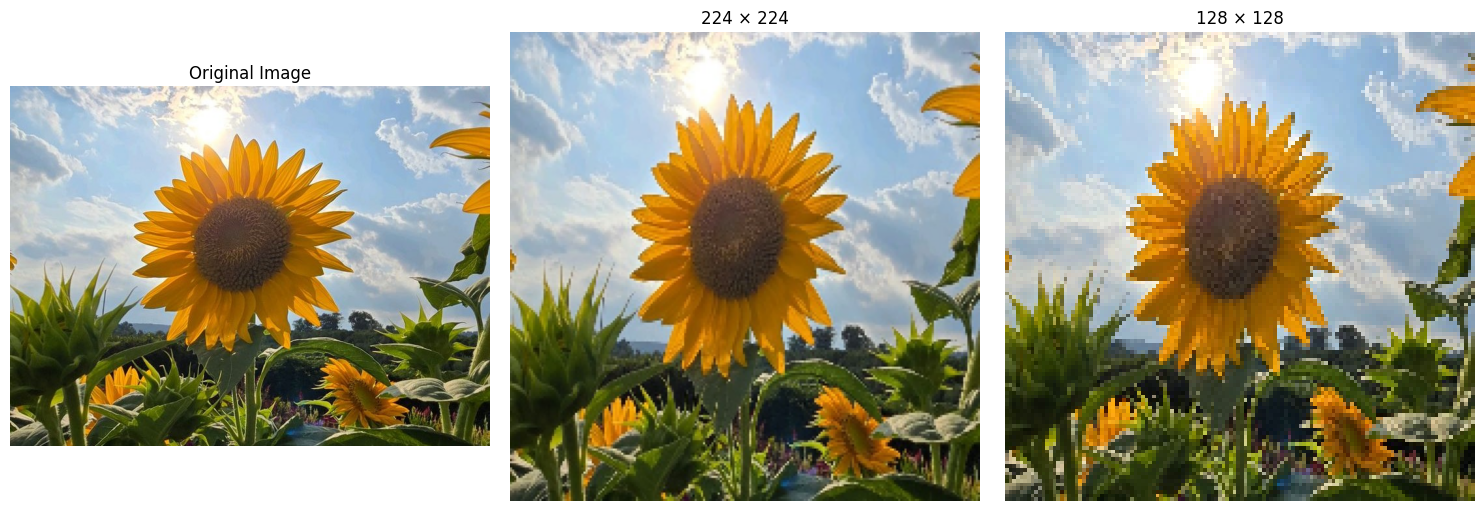

In [7]:
# Resize image to 224 x 224
resize_224 = cv2.resize(
    image,
    (224, 224),
    interpolation=cv2.INTER_LINEAR
)

# Resize image to 128 x 128
resize_128 = cv2.resize(
    image,
    (128, 128),
    interpolation=cv2.INTER_LINEAR
)

# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(rgb_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(resize_224, cv2.COLOR_BGR2RGB))
plt.title("224 × 224")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(resize_128, cv2.COLOR_BGR2RGB))
plt.title("128 × 128")
plt.axis("off")

plt.tight_layout()
plt.show()

# Task 4 – Cropping / Region of Interest (ROI)

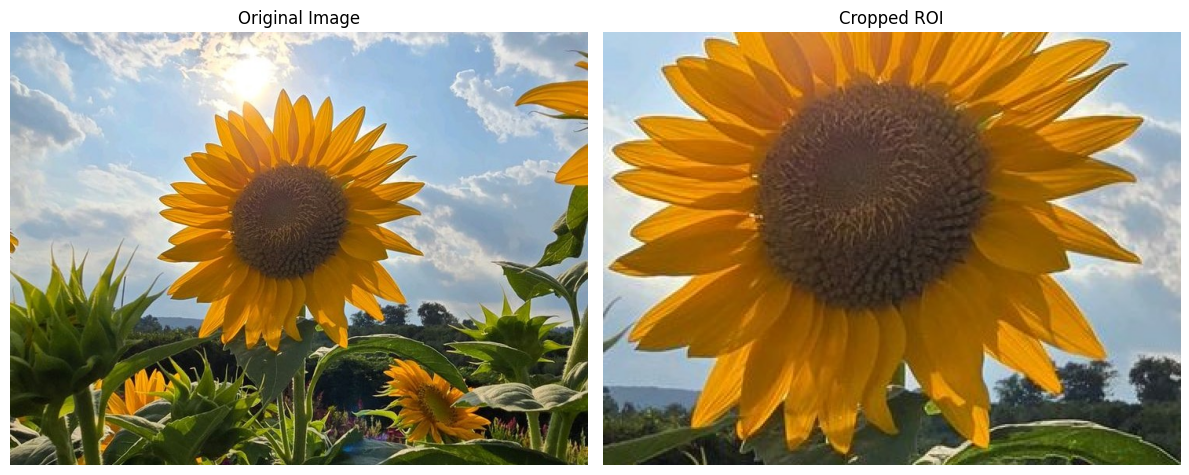

In [8]:
height, width = image.shape[:2]

# Define center region
x1 = width // 4
y1 = height // 4
x2 = 3 * width // 4
y2 = 3 * height // 4

# Crop the image
roi = image[y1:y2, x1:x2]

# Display original and cropped image
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title("Cropped ROI")
plt.axis("off")

plt.tight_layout()
plt.show()

# Task 5 – Image Normalization

In [9]:
# Convert image to floating point
normalized_image = image.astype(np.float32) / 255.0

print("Original Image Range:")
print("Minimum:", image.min())
print("Maximum:", image.max())

print("\nNormalized Image Range:")
print("Minimum:", normalized_image.min())
print("Maximum:", normalized_image.max())

Original Image Range:
Minimum: 0
Maximum: 255

Normalized Image Range:
Minimum: 0.0
Maximum: 1.0


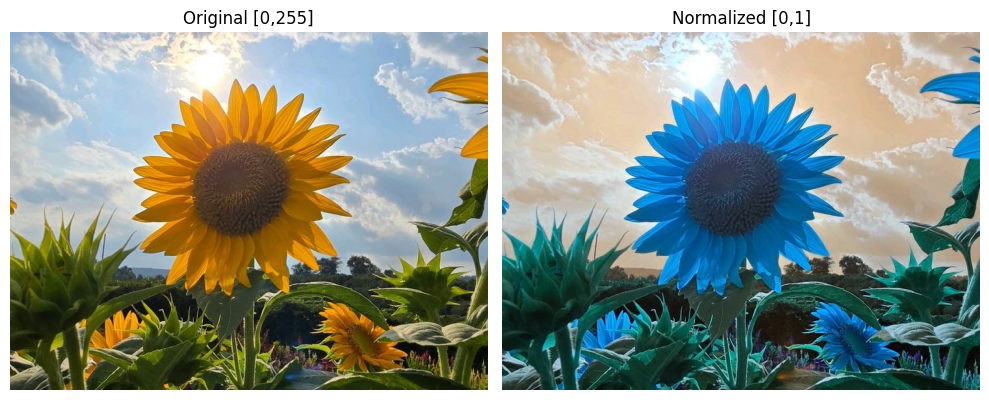

In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original [0,255]")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(normalized_image)
plt.title("Normalized [0,1]")
plt.axis("off")

plt.tight_layout()
plt.show()

# Task 6 – Histogram Equalization

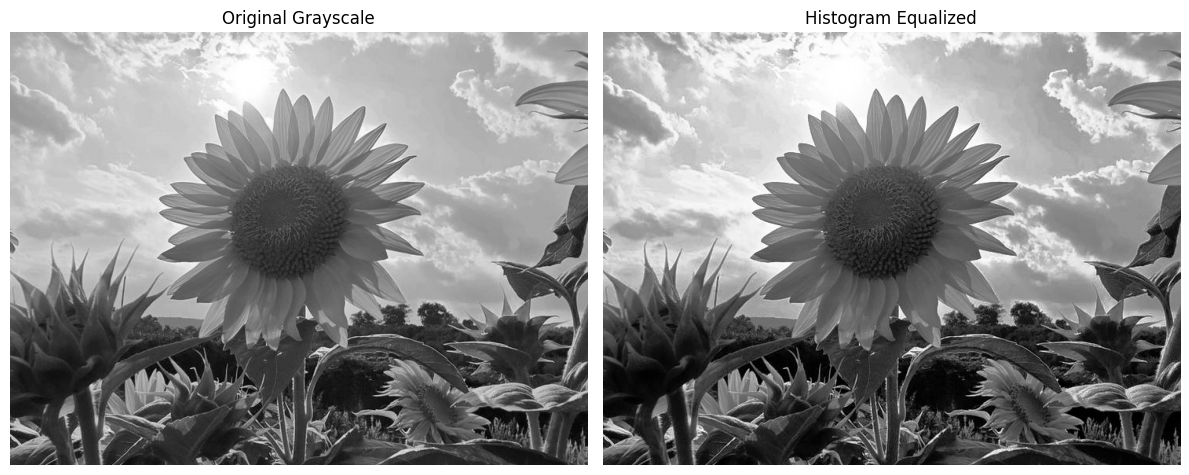

In [11]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply histogram equalization
equalized = cv2.equalizeHist(gray)

# Display images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalized")
plt.axis("off")

plt.tight_layout()
plt.show()

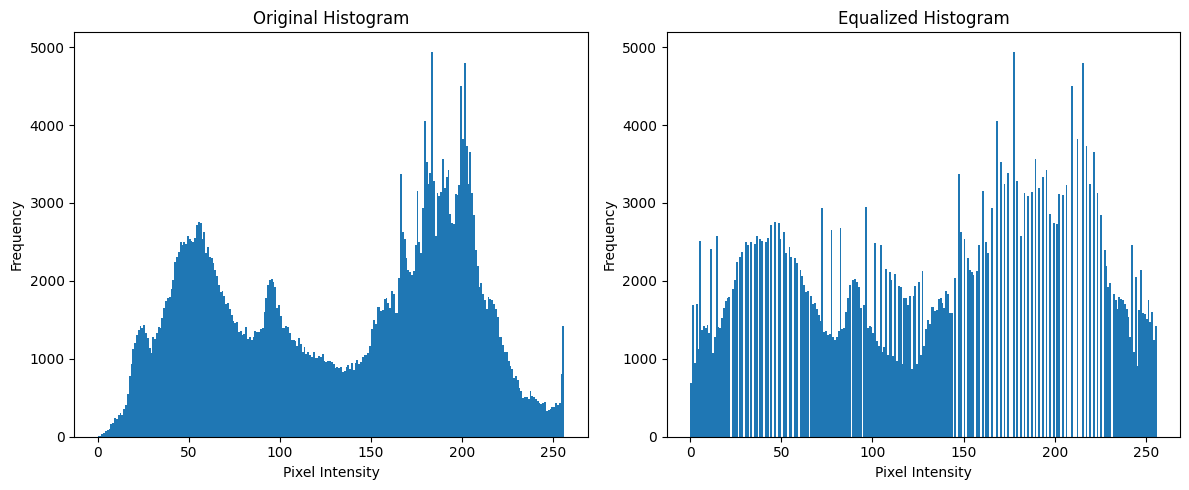

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(gray.ravel(), bins=256, range=[0, 256])
plt.title("Original Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(equalized.ravel(), bins=256, range=[0, 256])
plt.title("Equalized Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Task 7 – Noise Addition

In [13]:
# Convert image to float
image_float = image.astype(np.float32)

# Gaussian noise parameters
mean = 0
sigma = 25

# Generate Gaussian noise
gaussian_noise = np.random.normal(
    mean,
    sigma,
    image.shape
)

# Add noise
gaussian_noisy = image_float + gaussian_noise

# Keep values between 0 and 255
gaussian_noisy = np.clip(
    gaussian_noisy,
    0,
    255
).astype(np.uint8)

In [14]:
salt_pepper = image.copy()

amount = 0.03

num_pixels = int(
    amount * image.shape[0] * image.shape[1]
)

# Add salt noise
for _ in range(num_pixels // 2):
    y = np.random.randint(0, image.shape[0])
    x = np.random.randint(0, image.shape[1])
    salt_pepper[y, x] = [255, 255, 255]

# Add pepper noise
for _ in range(num_pixels // 2):
    y = np.random.randint(0, image.shape[0])
    x = np.random.randint(0, image.shape[1])
    salt_pepper[y, x] = [0, 0, 0]

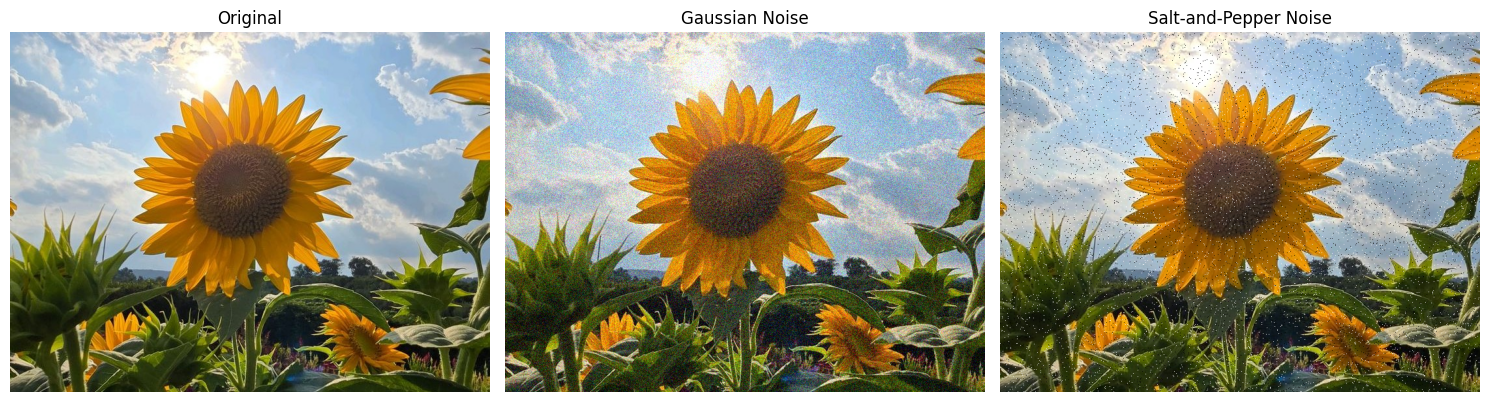

In [15]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(rgb_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(gaussian_noisy, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(salt_pepper, cv2.COLOR_BGR2RGB))
plt.title("Salt-and-Pepper Noise")
plt.axis("off")

plt.tight_layout()
plt.show()

# Task 8 – Image Filtering

In [16]:
# Mean / Average filter
mean_filtered = cv2.blur(
    salt_pepper,
    (5, 5)
)

# Gaussian filter
gaussian_filtered = cv2.GaussianBlur(
    salt_pepper,
    (5, 5),
    0
)

# Median filter
median_filtered = cv2.medianBlur(
    salt_pepper,
    5
)

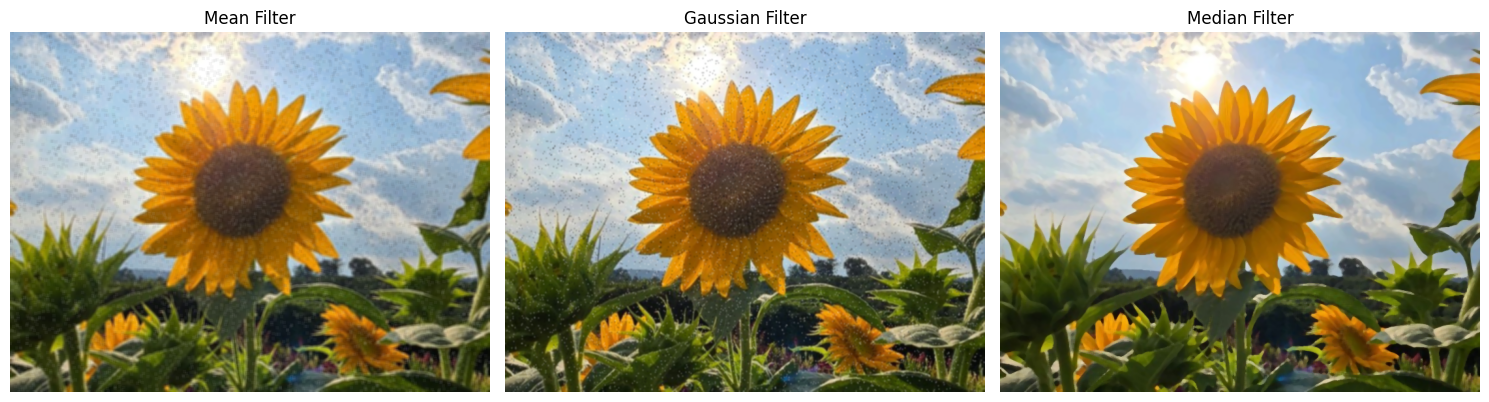

In [17]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(mean_filtered, cv2.COLOR_BGR2RGB))
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(gaussian_filtered, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(median_filtered, cv2.COLOR_BGR2RGB))
plt.title("Median Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

# Task 9 – Thresholding

In [18]:
# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Fixed binary threshold
threshold_value = 127

_, binary_threshold = cv2.threshold(
    gray,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

# Otsu thresholding
otsu_value, otsu_threshold = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Fixed Threshold:", threshold_value)
print("Otsu Threshold:", otsu_value)

Fixed Threshold: 127
Otsu Threshold: 126.0


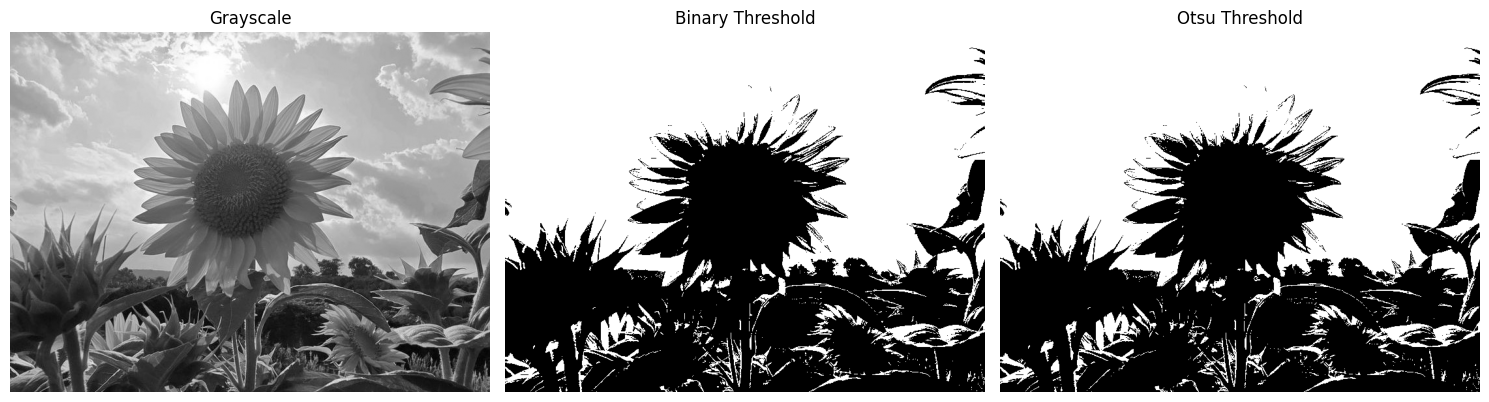

In [19]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(binary_threshold, cmap="gray")
plt.title("Binary Threshold")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.tight_layout()
plt.show()

# Task 10 – Morphological Processing

In [20]:
kernel = np.ones((5, 5), np.uint8)

In [21]:
erosion = cv2.erode(
    binary_threshold,
    kernel,
    iterations=1
)

In [22]:
dilation = cv2.dilate(
    binary_threshold,
    kernel,
    iterations=1
)

In [23]:
opening = cv2.morphologyEx(
    binary_threshold,
    cv2.MORPH_OPEN,
    kernel
)

In [24]:
closing = cv2.morphologyEx(
    binary_threshold,
    cv2.MORPH_CLOSE,
    kernel
)

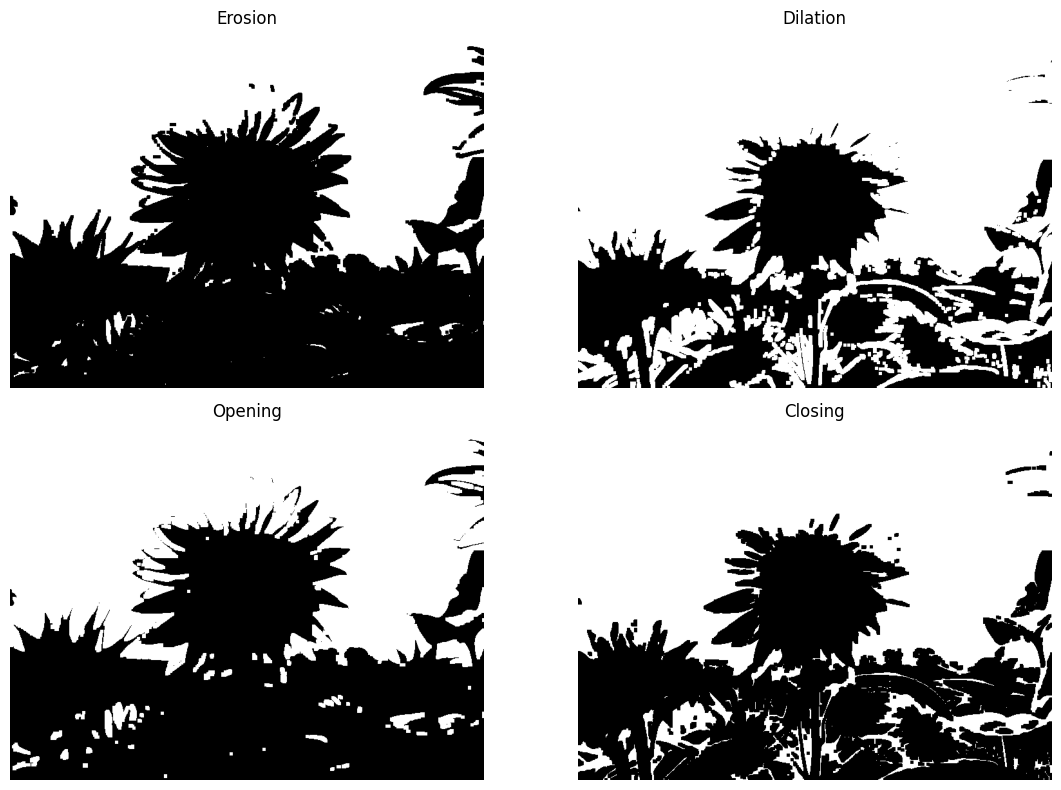

In [25]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(erosion, cmap="gray")
plt.title("Erosion")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(dilation, cmap="gray")
plt.title("Dilation")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(opening, cmap="gray")
plt.title("Opening")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(closing, cmap="gray")
plt.title("Closing")
plt.axis("off")

plt.tight_layout()
plt.show()

# Comparative Analysis

## 1. Mean vs Gaussian vs Median Filter

Mean filtering smooths the image by averaging neighboring pixels.
Gaussian filtering performs weighted smoothing.
Median filtering is especially effective for salt-and-pepper noise and generally preserves edges better.

## 2. Original vs Histogram Equalization

Histogram equalization improves contrast by redistributing pixel intensity values.

## 3. Fixed Threshold vs Otsu Threshold

Fixed thresholding uses a manually selected threshold value.
Otsu thresholding automatically determines a threshold from the image intensity distribution.

## 4. Erosion vs Dilation

Erosion reduces foreground regions.
Dilation expands foreground regions.

## 5. Opening vs Closing

Opening removes small foreground noise.
Closing fills small holes and connects small gaps.

# Conclusion

In this practical, various image preprocessing techniques were implemented using Python, OpenCV, NumPy, and Matplotlib. The practical included image loading, color conversion, resizing, cropping, normalization, histogram equalization, noise addition, filtering, thresholding, and morphological processing.

The experiment demonstrated that different preprocessing techniques are useful for different image-processing problems. Median filtering is effective for salt-and-pepper noise, histogram equalization improves contrast, thresholding separates foreground from background, and morphological operations modify binary image structures.

Therefore, selecting the appropriate preprocessing technique is important for obtaining better results in computer vision applications.